# E-Commerce Orders EDA

This notebook reviews 1,200 e-commerce order records from January 2023 through June 2025. The analysis focuses on a few practical questions: what drives order value, which products look strongest, how order status changes the revenue picture, and where the data stops short of supporting a stronger business claim.

### Executive Summary

- `Chair` generated the highest revenue, while `Printer` had the highest order count. Volume and value are telling slightly different stories.
- `TotalPrice` is moderately right-skewed. A small number of high-value orders lift the mean above the median, so the average order value needs some context.
- `UnitPrice` has a stronger linear relationship with order value than `Quantity`. That is expected because order value is calculated from price and quantity, but it still helps show that product mix matters.
- `Cancelled` orders deserve attention because they are the largest order-status group and carry the largest gross revenue total. I would not call this a root-cause finding without cancellation reasons.
- `Instagram` has the highest referral-source revenue in this dataset. That is a useful observation, not proof that it is the best marketing channel.
- The data is clean and internally consistent, but it also looks very evenly distributed. Some patterns may reflect how the dataset was generated rather than real customer behavior.

## 1. Setup

The setup is kept short: load the core libraries, set plotting defaults, and define a few helper functions. I avoided turning this into a tutorial notebook so the analysis itself stays in focus.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
VISUALS_DIR = Path("../visuals")
SELECTED_VISUALS_DIR = VISUALS_DIR / "selected"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SELECTED_VISUALS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def clean_column_names(columns):
    return (
        pd.Index(columns)
        .str.strip()
        .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
        .str.strip("_")
        .str.lower()
    )


def save_selected_plot(filename, dpi=300):
    output_path = SELECTED_VISUALS_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {output_path}")


def iqr_outlier_summary(dataframe, columns):
    records = []
    for column in columns:
        q1 = dataframe[column].quantile(0.25)
        q3 = dataframe[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (dataframe[column] < lower) | (dataframe[column] > upper)
        records.append({
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_pct": round(outlier_mask.mean() * 100, 2),
        })
    return pd.DataFrame(records).sort_values("outlier_count", ascending=False)


def skewness_label(value):
    if value >= 1:
        return "highly right-skewed"
    if value >= 0.5:
        return "moderately right-skewed"
    if value > -0.5:
        return "approximately symmetric"
    if value > -1:
        return "moderately left-skewed"
    return "highly left-skewed"

## 2. Load and Prepare the Data

The assignment referenced a file name with `(1)`, while this repository contains the same dataset without that suffix. The notebook checks both names so it runs in the current folder without manual editing.

**Analyst note:** I would normally standardize file names before publishing a project. Here, keeping the fallback is useful because it makes the notebook more robust to the small naming mismatch.

In [3]:
primary_data_path = DATA_DIR / "Dataset for Data Analytics(1).xlsx"
fallback_data_path = DATA_DIR / "Dataset for Data Analytics.xlsx"

if primary_data_path.exists():
    data_path = primary_data_path
elif fallback_data_path.exists():
    data_path = fallback_data_path
else:
    raise FileNotFoundError("Could not find the e-commerce dataset in the data folder.")

raw_df = pd.read_excel(data_path)
df = raw_df.copy()
df.columns = clean_column_names(df.columns)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["order_year"] = df["date"].dt.year
df["order_month"] = df["date"].dt.to_period("M").astype(str)
df["order_quarter"] = df["date"].dt.to_period("Q").astype(str)
df["day_of_week"] = df["date"].dt.day_name()

df["couponcode"] = df["couponcode"].fillna("No Coupon")
df["calculated_total_price"] = df["quantity"] * df["unitprice"]
df["total_price_difference"] = df["totalprice"] - df["calculated_total_price"]

print(f"Loaded file: {data_path}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns after feature engineering: {df.shape[1]:,}")
display(df.head())

Loaded file: ..\data\Dataset for Data Analytics.xlsx
Rows: 1,200
Columns after feature engineering: 20


,orderid,date,customerid,product,quantity,unitprice,shippingaddress,paymentmethod,orderstatus,trackingnumber,itemsincart,couponcode,referralsource,totalprice,order_year,order_month,order_quarter,day_of_week,calculated_total_price,total_price_difference
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10",2023,2023-01,2023Q1,Wednesday,"2,853.10",0.00
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,2024-08,2024Q3,Friday,302.70,0.00
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40",2024,2024-02,2024Q1,Tuesday,"2,753.40",0.00
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,2023-10,2023Q4,Sunday,273.19,0.00
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04",2025,2025-05,2025Q2,Thursday,"2,504.04",0.00


## 3. Dataset Profile

The dataset is order-level: one row represents one transaction. It is not a customer table, and it is not a product catalog. That matters because customer behavior and product performance can only be inferred from order records.

In [4]:
column_dictionary = pd.DataFrame([
    ["orderid", "Unique order identifier", "identifier"],
    ["date", "Order date", "datetime"],
    ["customerid", "Customer identifier", "identifier"],
    ["product", "Product ordered", "categorical"],
    ["quantity", "Units ordered", "numeric"],
    ["unitprice", "Unit selling price", "numeric"],
    ["shippingaddress", "Shipping address text", "categorical"],
    ["paymentmethod", "Payment method used", "categorical"],
    ["orderstatus", "Current order state", "categorical"],
    ["trackingnumber", "Shipping tracking identifier", "identifier"],
    ["itemsincart", "Items in cart at purchase", "numeric"],
    ["couponcode", "Coupon used, or No Coupon", "categorical"],
    ["referralsource", "Referral/acquisition source", "categorical"],
    ["totalprice", "Order revenue", "numeric"],
])
column_dictionary.columns = ["column", "meaning", "analytical_role"]
display(column_dictionary)

numeric_columns = ["quantity", "unitprice", "itemsincart", "totalprice"]
categorical_columns = ["product", "paymentmethod", "orderstatus", "couponcode", "referralsource"]

dtype_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "unique_values": df.nunique(dropna=True).values,
})
display(dtype_profile)

,column,meaning,analytical_role
0,orderid,Unique order identifier,identifier
1,date,Order date,datetime
2,customerid,Customer identifier,identifier
3,product,Product ordered,categorical
4,quantity,Units ordered,numeric
5,unitprice,Unit selling price,numeric
6,shippingaddress,Shipping address text,categorical
7,paymentmethod,Payment method used,categorical
8,orderstatus,Current order state,categorical
9,trackingnumber,Shipping tracking identifier,identifier


,column,dtype,non_null,unique_values
0,orderid,object,1200,1200
1,date,datetime64[ns],1200,671
2,customerid,object,1200,1189
3,product,object,1200,7
4,quantity,int64,1200,5
5,unitprice,float64,1200,1193
6,shippingaddress,object,1200,655
7,paymentmethod,object,1200,5
8,orderstatus,object,1200,5
9,trackingnumber,object,1200,1200


## 4. Data Reliability Audit

Before looking for patterns, I checked whether the basics were trustworthy: missing values, duplicate rows, ID uniqueness, date coverage, and whether the revenue field matches `Quantity x UnitPrice`.

In [5]:
audit_summary = pd.DataFrame({
    "check": [
        "Raw row count",
        "Original column count",
        "Duplicate rows",
        "Missing values after coupon treatment",
        "Unique order IDs",
        "Unique tracking numbers",
        "Unique customers",
        "Date range",
        "Max revenue formula difference",
    ],
    "result": [
        f"{len(raw_df):,}",
        f"{raw_df.shape[1]:,}",
        f"{df.duplicated().sum():,}",
        f"{df.isna().sum().sum():,}",
        f"{df['orderid'].nunique():,}",
        f"{df['trackingnumber'].nunique():,}",
        f"{df['customerid'].nunique():,}",
        f"{df['date'].min().date()} to {df['date'].max().date()}",
        f"{df['total_price_difference'].abs().max():,.6f}",
    ],
})
display(audit_summary)

original_missing = raw_df.isna().sum().rename("missing_count").to_frame()
original_missing["missing_pct"] = (raw_df.isna().mean() * 100).round(2)
display(original_missing[original_missing["missing_count"] > 0])

,check,result
0,Raw row count,"1,200"
1,Original column count,14
2,Duplicate rows,0
3,Missing values after coupon treatment,0
4,Unique order IDs,"1,200"
5,Unique tracking numbers,"1,200"
6,Unique customers,"1,189"
7,Date range,2023-01-01 to 2025-06-30
8,Max revenue formula difference,0.000000


,missing_count,missing_pct
CouponCode,309,25.75


### Data Quality Notes

- `OrderID` and `TrackingNumber` are unique, which supports treating each row as one order.
- `CustomerID` repeats in a small number of cases. That is plausible, but there is not enough history here for serious retention or cohort analysis.
- `TotalPrice` exactly matches `Quantity x UnitPrice`, so the revenue field is internally consistent.
- `CouponCode` blanks are more reasonably interpreted as no coupon rather than unknown data.
- The category distributions are very tidy. That does not invalidate the EDA, but it does make me cautious about over-reading small differences between groups.

## 5. Descriptive Statistics and Order Value Shape

The main question here is simple: does the average order value describe a typical order well? Not entirely. `TotalPrice` is right-skewed, so the median and the high-value tail deserve attention too.

In [6]:
descriptive_stats = df[numeric_columns].describe().T
descriptive_stats["skewness"] = df[numeric_columns].skew()
descriptive_stats["shape"] = descriptive_stats["skewness"].apply(skewness_label)
display(descriptive_stats)

outlier_summary = iqr_outlier_summary(df, numeric_columns)
display(outlier_summary)

,count,mean,std,min,25%,50%,75%,max,skewness,shape
quantity,"1,200.00",2.95,1.41,1.00,2.00,3.00,4.00,5.00,0.03,approximately symmetric
unitprice,"1,200.00",356.41,197.18,11.39,186.06,364.21,521.57,699.93,-0.03,approximately symmetric
itemsincart,"1,200.00",5.49,2.28,1.00,4.00,5.00,7.00,10.00,0.00,approximately symmetric
totalprice,"1,200.00","1,053.97",819.86,11.39,410.52,823.62,"1,578.47","3,456.40",0.89,moderately right-skewed


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
3,totalprice,410.52,"1,578.47","1,167.95","-1,341.41","3,330.41",8,0.67
0,quantity,2.00,4.00,2.00,-1.00,7.00,0,0.00
1,unitprice,186.06,521.57,335.51,-317.20,"1,024.83",0,0.00
2,itemsincart,4.00,7.00,3.00,-0.50,11.50,0,0.00


Saved: ..\visuals\selected\order_value_distribution_and_outliers.png


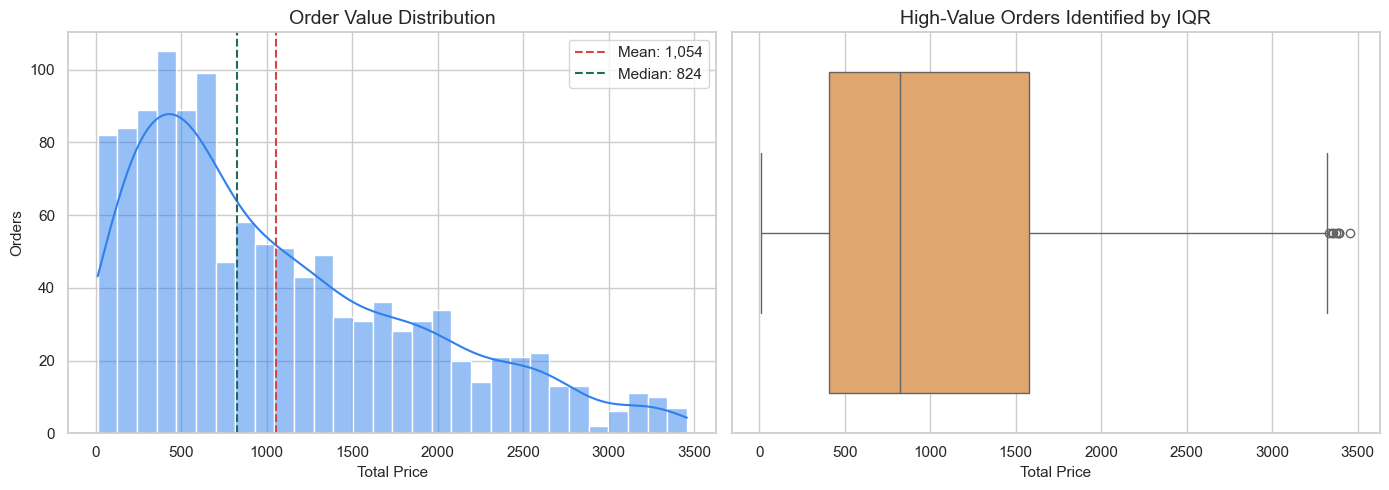

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["totalprice"], kde=True, bins=30, ax=axes[0], color="#2F80ED")
axes[0].axvline(df["totalprice"].mean(), color="#D64545", linestyle="--", label=f"Mean: {df['totalprice'].mean():,.0f}")
axes[0].axvline(df["totalprice"].median(), color="#206A5D", linestyle="--", label=f"Median: {df['totalprice'].median():,.0f}")
axes[0].set_title("Order Value Distribution")
axes[0].set_xlabel("Total Price")
axes[0].set_ylabel("Orders")
axes[0].legend()

sns.boxplot(data=df, x="totalprice", ax=axes[1], color="#F2A65A")
axes[1].set_title("High-Value Orders Identified by IQR")
axes[1].set_xlabel("Total Price")

save_selected_plot("order_value_distribution_and_outliers.png")
plt.show()

### Interpretation

`TotalPrice` has a skewness of about `0.89`, which is moderately right-skewed. The mean order value is above the median because a small group of larger orders pulls it upward.

**Analyst note:** The eight IQR outliers look more like valid high-value orders than data errors, especially because the revenue formula checks out. I would keep them in the analysis and flag them as a segment worth reviewing.

## 6. Product Performance

This section compares product revenue, order count, units sold, average order value, and revenue share. I am deliberately separating volume from value because the highest-order product is not necessarily the strongest revenue contributor.

,product,orders,units_sold,revenue,avg_order_value,avg_units_per_order,revenue_share_pct
0,Chair,178,562,"195,620.11","1,098.99",3.16,15.47
1,Printer,181,542,"195,612.61","1,080.73",2.99,15.47
2,Laptop,173,535,"192,126.56","1,110.56",3.09,15.19
3,Tablet,179,497,"186,568.95","1,042.28",2.78,14.75
4,Monitor,163,480,"175,651.41","1,077.62",2.94,13.89
5,Desk,170,508,"167,459.93",985.06,2.99,13.24
6,Phone,156,411,"151,722.39",972.58,2.63,12.00


Saved: ..\visuals\selected\revenue_by_product.png


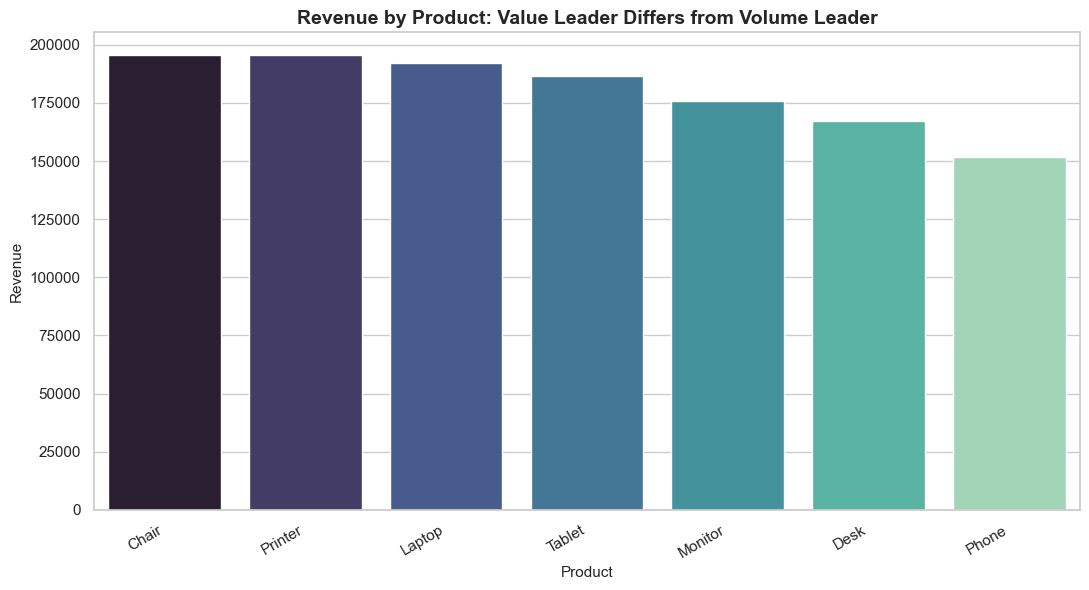

In [8]:
product_summary = (
    df.groupby("product")
    .agg(
        orders=("orderid", "count"),
        units_sold=("quantity", "sum"),
        revenue=("totalprice", "sum"),
        avg_order_value=("totalprice", "mean"),
        avg_units_per_order=("quantity", "mean"),
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)
product_summary["revenue_share_pct"] = (product_summary["revenue"] / product_summary["revenue"].sum() * 100).round(2)
display(product_summary)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=product_summary, x="product", y="revenue", palette="mako")
ax.set_title("Revenue by Product: Value Leader Differs from Volume Leader", weight="bold")
ax.set_xlabel("Product")
ax.set_ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
save_selected_plot("revenue_by_product.png")
plt.show()

### Interpretation

`Chair` leads revenue, while `Printer` leads order count. That difference is small but useful: product performance depends on both demand and order value. `Phone` is lowest by revenue in this dataset, although I would avoid calling it a weak product without margin, inventory, or customer-demand context.

## 7. Fulfillment Status and Revenue at Risk

Order status is one of the more useful fields here because it changes how revenue should be interpreted. Revenue tied to cancelled or returned orders should not be treated the same as delivered revenue.

,orderstatus,orders,revenue,avg_order_value,order_share_pct,revenue_share_pct
0,Cancelled,250,"276,396.21","1,105.58",20.83,21.85
1,Pending,237,"256,328.15","1,081.55",19.75,20.27
2,Shipped,235,"246,159.58","1,047.49",19.58,19.46
3,Returned,247,"243,277.70",984.93,20.58,19.24
4,Delivered,231,"242,600.32","1,050.22",19.25,19.18


Saved: ..\visuals\selected\gross_revenue_by_order_status.png


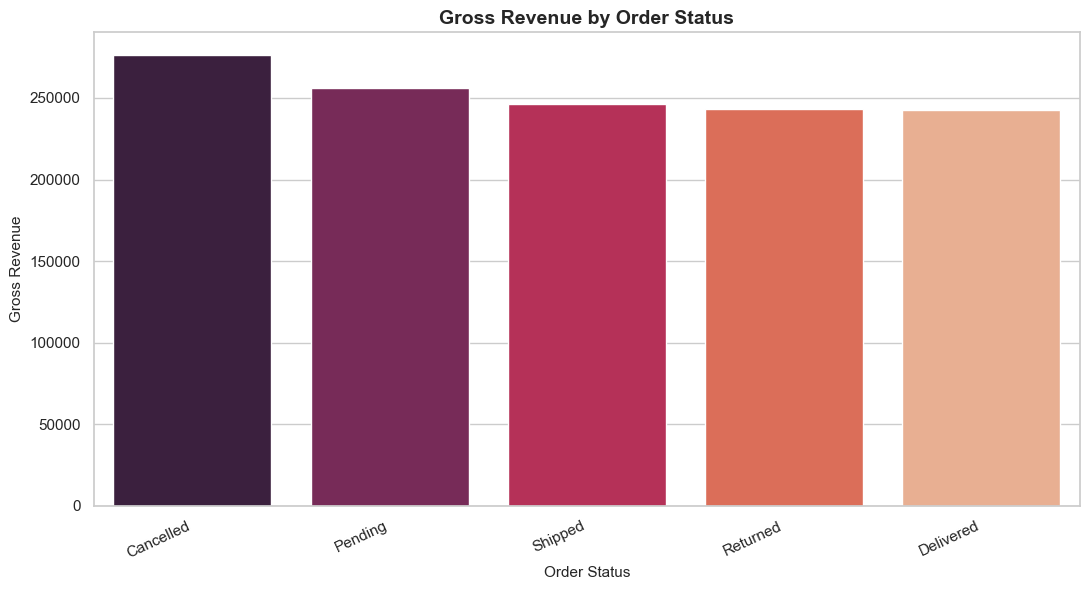

In [9]:
status_summary = (
    df.groupby("orderstatus")
    .agg(
        orders=("orderid", "count"),
        revenue=("totalprice", "sum"),
        avg_order_value=("totalprice", "mean"),
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)
status_summary["order_share_pct"] = (status_summary["orders"] / status_summary["orders"].sum() * 100).round(2)
status_summary["revenue_share_pct"] = (status_summary["revenue"] / status_summary["revenue"].sum() * 100).round(2)
display(status_summary)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=status_summary, x="orderstatus", y="revenue", palette="rocket")
ax.set_title("Gross Revenue by Order Status", weight="bold")
ax.set_xlabel("Order Status")
ax.set_ylabel("Gross Revenue")
plt.xticks(rotation=25, ha="right")
save_selected_plot("gross_revenue_by_order_status.png")
plt.show()

### Interpretation

`Cancelled` is both the largest status by order count and the largest status by gross revenue. That is worth investigating, but it is not a diagnosis by itself. The dataset does not include cancellation reasons, stock availability, payment failures, or delivery timing.

**Analyst note:** In a real business setting, this would be the first area I would ask follow-up questions about. In this dataset, it may also reflect randomized status assignment.

## 8. Acquisition, Coupon, and Payment Behavior

Referral source, coupon code, and payment method are useful segmentation fields, but the interpretation has to stay modest. The data includes revenue and order counts, not campaign spend, discount cost, or margin.

In [10]:
referral_summary = (
    df.groupby("referralsource")
    .agg(orders=("orderid", "count"), revenue=("totalprice", "sum"), avg_order_value=("totalprice", "mean"))
    .sort_values("revenue", ascending=False)
    .reset_index()
)
coupon_summary = (
    df.groupby("couponcode")
    .agg(orders=("orderid", "count"), revenue=("totalprice", "sum"), avg_order_value=("totalprice", "mean"))
    .sort_values("avg_order_value", ascending=False)
    .reset_index()
)
payment_summary = (
    df.groupby("paymentmethod")
    .agg(orders=("orderid", "count"), revenue=("totalprice", "sum"), avg_order_value=("totalprice", "mean"))
    .sort_values("avg_order_value", ascending=False)
    .reset_index()
)

display(referral_summary)
display(coupon_summary)
display(payment_summary)

,referralsource,orders,revenue,avg_order_value
0,Instagram,259,"275,285.45","1,062.88"
1,Email,250,"261,808.55","1,047.23"
2,Google,241,"250,441.48","1,039.18"
3,Facebook,228,"250,410.90","1,098.29"
4,Referral,222,"226,815.58","1,021.69"


,couponcode,orders,revenue,avg_order_value
0,FREESHIP,313,"335,036.99","1,070.41"
1,SAVE10,286,"304,840.02","1,065.87"
2,No Coupon,309,"322,401.41","1,043.37"
3,WINTER15,292,"302,483.54","1,035.90"


,paymentmethod,orders,revenue,avg_order_value
0,Credit Card,234,"263,847.63","1,127.55"
1,Gift Card,230,"246,323.92","1,070.97"
2,Cash,246,"259,786.29","1,056.04"
3,Online,258,"262,442.94","1,017.22"
4,Debit Card,232,"232,361.18","1,001.56"


Saved: ..\visuals\selected\channel_and_coupon_performance.png


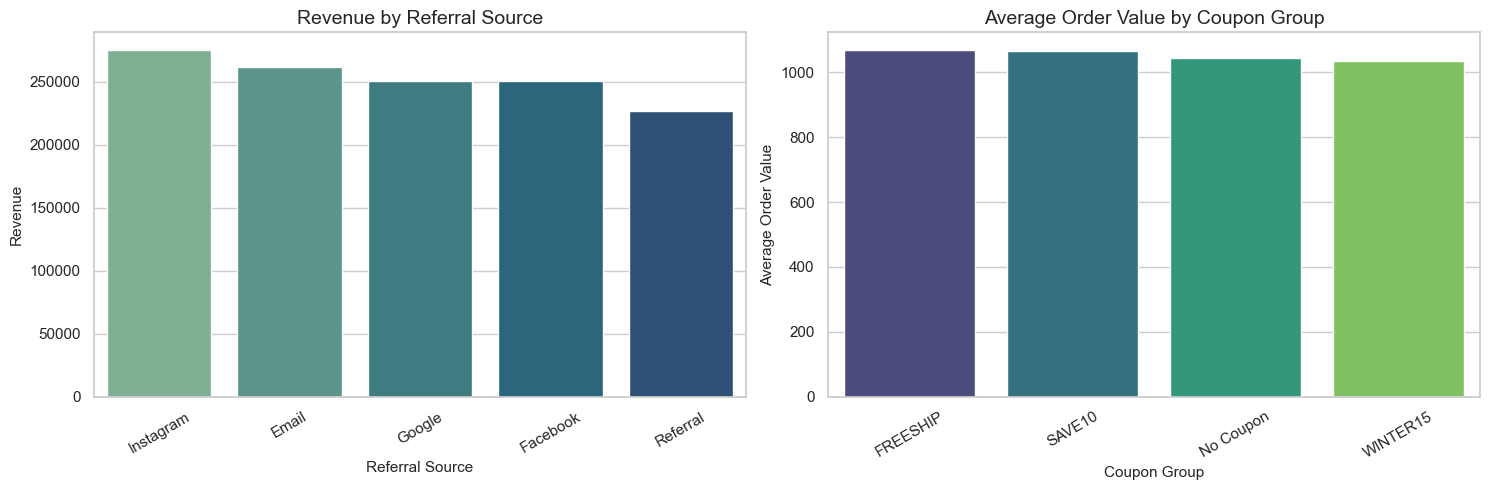

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=referral_summary, x="referralsource", y="revenue", ax=axes[0], palette="crest")
axes[0].set_title("Revenue by Referral Source")
axes[0].set_xlabel("Referral Source")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=coupon_summary, x="couponcode", y="avg_order_value", ax=axes[1], palette="viridis")
axes[1].set_title("Average Order Value by Coupon Group")
axes[1].set_xlabel("Coupon Group")
axes[1].set_ylabel("Average Order Value")
axes[1].tick_params(axis="x", rotation=30)

save_selected_plot("channel_and_coupon_performance.png")
plt.show()

### Interpretation

`Instagram` produces the highest referral-source revenue. That makes it a candidate for deeper marketing review, but not automatically the best channel. `FREESHIP` has the highest average order value among coupon groups, although the actual shipping subsidy cost is missing. `Credit Card` has the highest average order value by payment method; useful to note, but not something I would act on without more customer context.

## 9. Revenue Drivers and Relationships

Correlation is used here as a descriptive tool. Since `TotalPrice` is built from price and quantity, these relationships are partly mechanical. The goal is not to discover causality, but to understand how order value is structured in this dataset.

,quantity,unitprice,itemsincart,totalprice
quantity,1.00,0.01,0.65,0.62
unitprice,0.01,1.00,0.00,0.72
itemsincart,0.65,0.00,1.00,0.39
totalprice,0.62,0.72,0.39,1.00


Saved: ..\visuals\selected\revenue_driver_relationships.png


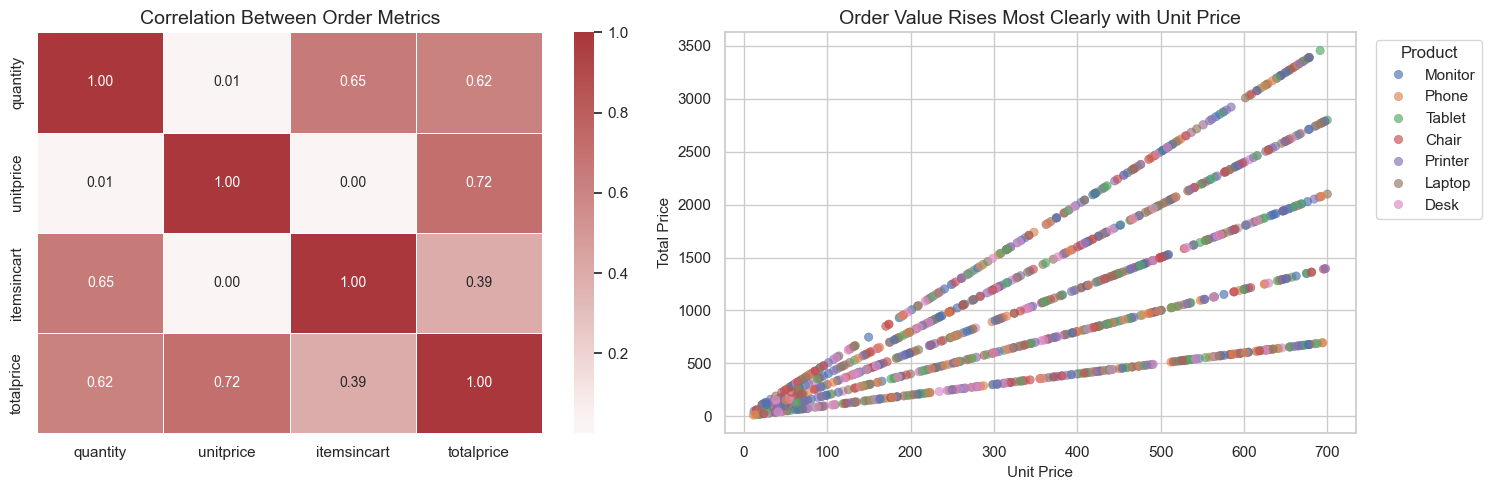

In [12]:
correlation_columns = ["quantity", "unitprice", "itemsincart", "totalprice"]
correlation_matrix = df[correlation_columns].corr()
display(correlation_matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(correlation_matrix, annot=True, cmap="vlag", center=0, fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Between Order Metrics")

sns.scatterplot(data=df, x="unitprice", y="totalprice", hue="product", alpha=0.65, edgecolor=None, ax=axes[1])
axes[1].set_title("Order Value Rises Most Clearly with Unit Price")
axes[1].set_xlabel("Unit Price")
axes[1].set_ylabel("Total Price")
axes[1].legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")

save_selected_plot("revenue_driver_relationships.png")
plt.show()

### Interpretation

`UnitPrice` has the strongest relationship with `TotalPrice`, followed by `Quantity`. `ItemsInCart` is related to quantity but much less strongly related to revenue. Put differently, larger carts do not always become higher-value orders unless they include higher-priced items or more units.

**Analyst note:** This is one place where the math and the business interpretation overlap. The correlation is real, but it should not be framed as a surprising predictive insight.

## 10. Time-Based Performance

The monthly view is useful for spotting periods that deserve follow-up. I would be careful about calling anything seasonality here because the dataset covers only two full years plus half of 2025, and there is no campaign or inventory calendar.

,order_month,orders,revenue,avg_order_value,units_sold,order_month_dt,revenue_3m_rolling_avg
17,2024-06,53,"68,068.54","1,284.31",166,2024-06-01,"48,530.26"
4,2023-05,49,"63,836.84","1,302.79",148,2023-05-01,"46,732.64"
0,2023-01,47,"56,685.75","1,206.08",146,2023-01-01,"56,685.75"
7,2023-08,51,"54,352.14","1,065.73",174,2023-08-01,"48,891.00"
29,2025-06,49,"53,047.40","1,082.60",146,2025-06-01,"42,755.08"
9,2023-10,47,"52,607.85","1,119.32",150,2023-10-01,"45,495.55"
15,2024-04,50,"49,613.14",992.26,147,2024-04-01,"40,851.20"
5,2023-06,45,"49,500.19","1,100.00",146,2023-06-01,"47,029.58"


Saved: ..\visuals\selected\monthly_revenue_trend.png


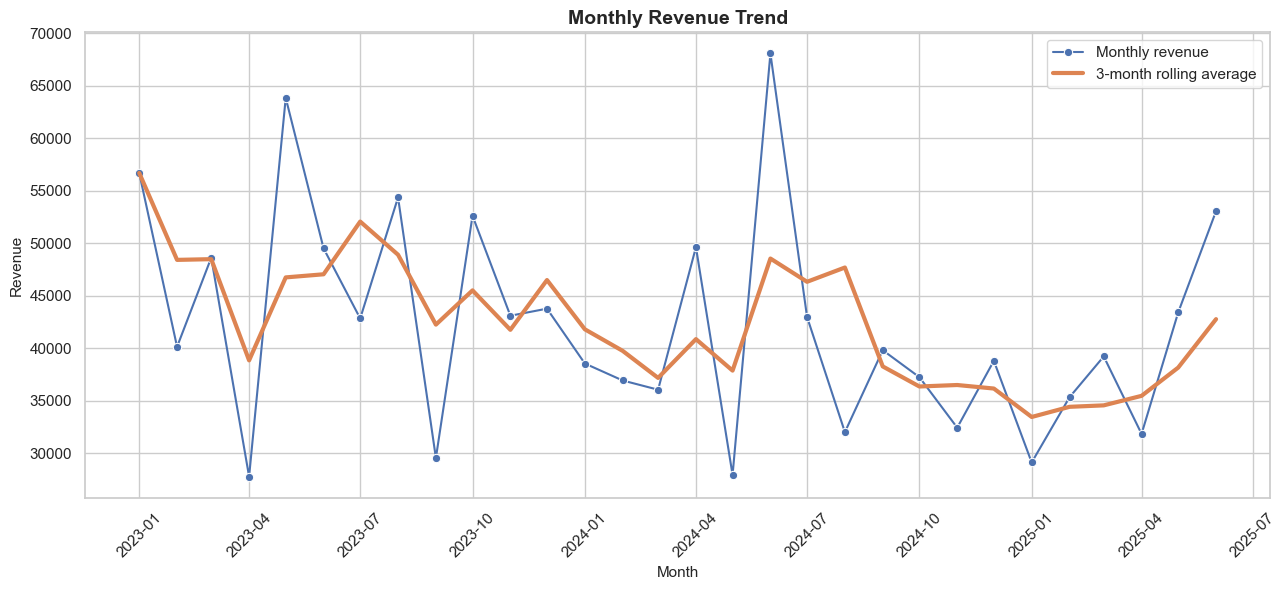

In [13]:
monthly_summary = (
    df.groupby("order_month")
    .agg(
        orders=("orderid", "count"),
        revenue=("totalprice", "sum"),
        avg_order_value=("totalprice", "mean"),
        units_sold=("quantity", "sum"),
    )
    .reset_index()
)
monthly_summary["order_month_dt"] = pd.to_datetime(monthly_summary["order_month"])
monthly_summary = monthly_summary.sort_values("order_month_dt")
monthly_summary["revenue_3m_rolling_avg"] = monthly_summary["revenue"].rolling(3, min_periods=1).mean()

display(monthly_summary.sort_values("revenue", ascending=False).head(8))

plt.figure(figsize=(13, 6))
sns.lineplot(data=monthly_summary, x="order_month_dt", y="revenue", marker="o", label="Monthly revenue")
sns.lineplot(data=monthly_summary, x="order_month_dt", y="revenue_3m_rolling_avg", linewidth=3, label="3-month rolling average")
plt.title("Monthly Revenue Trend", weight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
save_selected_plot("monthly_revenue_trend.png")
plt.show()

### Interpretation

June 2024 is the strongest revenue month in the dataset. That is a useful flag, not an explanation. To understand why, I would want campaign timing, stock availability, fulfillment status changes, and possibly product-level promotions.

## 11. Cross-Segment View

This heatmap connects product performance with order status. It is useful because a product can look strong in gross revenue while still having a meaningful share of that revenue tied to cancelled or returned orders.

orderstatus,Cancelled,Delivered,Pending,Returned,Shipped
product,,,,,
Chair,"48,660.98","31,465.83","48,504.70","26,638.16","40,350.44"
Desk,"39,587.69","24,225.78","41,390.08","28,831.49","33,424.89"
Laptop,"43,761.72","40,714.43","27,758.88","39,654.30","40,237.23"
Monitor,"37,057.44","35,999.62","31,144.93","40,524.60","30,924.82"
Phone,"28,023.26","40,345.41","32,192.88","29,164.20","21,996.64"
Printer,"38,675.16","38,054.73","38,546.22","35,939.09","44,397.41"
Tablet,"40,629.96","31,794.52","36,790.46","42,525.86","34,828.15"


Saved: ..\visuals\selected\product_status_revenue_heatmap.png


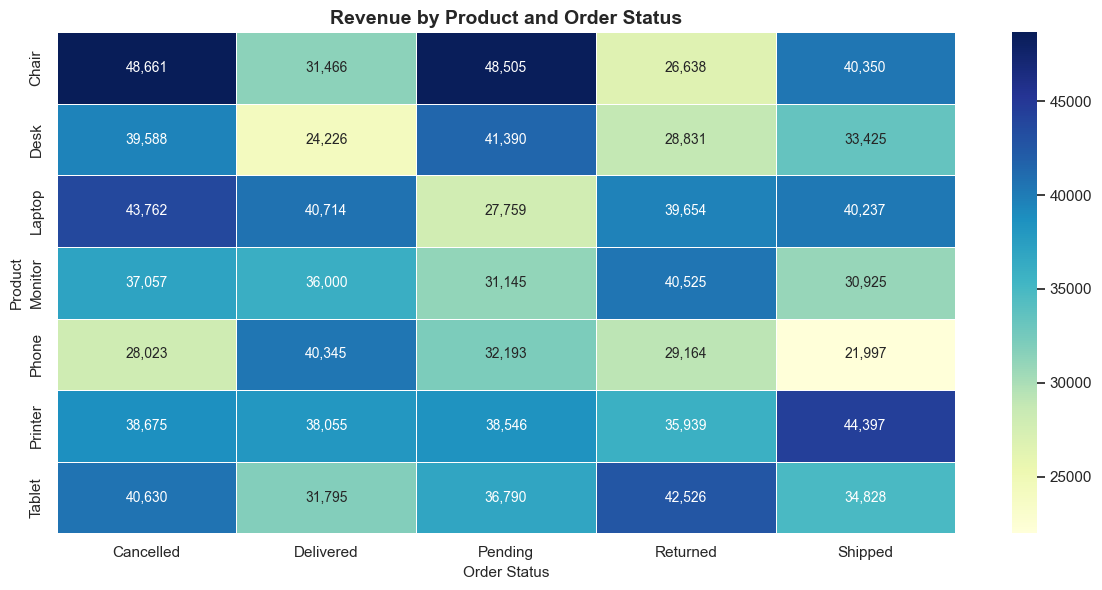

In [14]:
product_status_revenue = pd.pivot_table(
    df,
    index="product",
    columns="orderstatus",
    values="totalprice",
    aggfunc="sum",
    fill_value=0,
)
display(product_status_revenue)

plt.figure(figsize=(12, 6))
sns.heatmap(product_status_revenue, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Revenue by Product and Order Status", weight="bold")
plt.xlabel("Order Status")
plt.ylabel("Product")
save_selected_plot("product_status_revenue_heatmap.png")
plt.show()

## 12. Analytical Limitations and Data Reliability

These limitations are part of the analysis, not an afterthought.

- **Possible synthetic structure:** Products, statuses, payment methods, referral sources, and coupons are unusually balanced. That is common in training datasets. The analysis is still useful, but I would not treat small differences as strong evidence of real customer behavior.
- **Revenue is not profit:** Product cost, shipping cost, coupon cost, refund amount, and margin are missing. A high-revenue product or channel may not be the most profitable one.
- **No causal inference:** Correlations describe relationships in the observed data. They do not prove that changing price, coupon strategy, or referral source would cause revenue to change.
- **Transaction-only view:** The dataset has customer IDs, but not demographics, acquisition dates, lifecycle stage, session behavior, or full purchase history.
- **Missing operational context:** Order status is available, but cancellation reasons, return reasons, stock availability, and delivery time are not.
- **Coupon interpretation risk:** `FREESHIP` has strong average order value, but the shipping subsidy cost is unknown.
- **Limited time context:** Monthly trends are useful for review, but there is not enough context to prove seasonality.

## 13. Final Findings and Recommendations

### Findings

1. Product performance should be judged by both revenue and volume. `Chair` leads revenue, while `Printer` leads order count.
2. Order value is right-skewed, so median order value and high-value orders should be reported alongside the mean.
3. `Cancelled` orders carry enough gross revenue to justify follow-up, but the dataset does not explain the cause.
4. `Instagram` is the top referral source by revenue in this dataset; channel efficiency is still unknown.
5. `FREESHIP` is associated with the highest average order value, but profitability cannot be assessed without cost data.
6. Revenue is more closely tied to unit price than quantity, which points toward product mix as an important part of the revenue story.

### Recommendations

1. Separate gross revenue from realized revenue in future reporting, especially for cancelled and returned orders.
2. Investigate cancelled orders by product, month, and referral source once cancellation reasons or fulfillment timestamps are available.
3. Report median order value and high-value order counts alongside average order value.
4. Evaluate referral channels using revenue, cost, conversion rate, and margin before making budget decisions.
5. Add product cost, discount amount, shipping cost, and return cost if the analysis is extended into profitability.

**Analyst note:** The strongest next step is not another chart. It is better source data: costs, fulfillment timestamps, and cancellation/return reasons would improve the analysis more than adding extra visualizations.

## 14. Exported Outputs

The cleaned dataset and numeric summary are exported for reuse. A smaller set of main visuals is saved to `visuals/selected`, while earlier supporting charts are kept in `visuals/appendix`.

In [15]:
cleaned_output_path = REPORTS_DIR / "cleaned_ecommerce_orders.csv"
numeric_summary_path = REPORTS_DIR / "eda_numeric_summary.csv"

df.to_csv(cleaned_output_path, index=False)
descriptive_stats.to_csv(numeric_summary_path)

print(f"Cleaned data exported to: {cleaned_output_path}")
print(f"Numeric summary exported to: {numeric_summary_path}")
print(f"Selected visuals exported to: {SELECTED_VISUALS_DIR}")

Cleaned data exported to: ..\reports\cleaned_ecommerce_orders.csv
Numeric summary exported to: ..\reports\eda_numeric_summary.csv
Selected visuals exported to: ..\visuals\selected
